## Azure AI Evaluation Example

This notebook demonstrates how to configure and use the Azure AI Evaluation SDK to evaluate an agent using a critic agent. The setup includes loading environment variables, configuring the model, and running both synchronous and asynchronous evaluations.

- **Environment Setup:** Loads credentials and endpoints from a `.env` file.
- **Model Configuration:** Sets up the Azure OpenAI model configuration.
- **Critic Agent:** Instantiates a critic agent for evaluation tasks.
- **Evaluation:** Runs both standard and auto evaluation methods on the specified agent and project.

Refer to the code cells above for implementation details.

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import os
from azure.ai.evaluation import AzureOpenAIModelConfiguration, AzureAIProject
from azure.ai.evaluation._agents._critic_agent import CriticAgent
from dotenv import load_dotenv


In [11]:
load_dotenv()

True

In [12]:
model_config = AzureOpenAIModelConfiguration(
    azure_endpoint=os.environ.get("AZURE_OPENAI_ENDPOINT"),
    api_key=os.environ.get("AZURE_OPENAI_API_KEY"),
    azure_deployment=os.environ.get("AZURE_OPENAI_DEPLOYMENT"),
    api_version=os.environ.get("AZURE_OPENAI_API_VERSION", "2024-02-01")
)
#
critic_agent = CriticAgent(model_config=model_config)

In [13]:
azure_ai_project = {
    "azure_endpoint": os.environ.get("PROJECT_ENDPOINT"),
}


### Streamlining

Evaluates an Agent/thread against the provided evaluators

In [14]:
critic_agent.evaluate(agent_id="asst_8LTtd9HiRi1tABmOIergHYPX", azure_ai_project=azure_ai_project, evaluators=['IntentResolution', 'TaskAdherence'])

Class AIAgentConverter: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class FDPAgentDataRetriever: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class AIAgentDataRetriever: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.


Fetched 5 threads for agent asst_8LTtd9HiRi1tABmOIergHYPX.
THREAD ID thread_Hv7zgjFSNw3mpKdzwEHyt4Iv
THREAD ID thread_SiADW12PSYbotYZw0Am90D8A
THREAD ID thread_2TSAHUokGHv6ARieCrF54GLX
THREAD ID thread_jam1ck1ZAm6O3959hvxhDQLh
THREAD ID thread_6134m2HpPP4INEtWKfCYM4G4


[{'thread_id': 'thread_Hv7zgjFSNw3mpKdzwEHyt4Iv',
  'results': {'TaskAdherence': {'task_adherence': 3.0,
    'task_adherence_result': 'pass',
    'task_adherence_threshold': 3,
    'task_adherence_reason': 'The assistant provided accurate pricing, plan details, a free trial link, and a follow-up question, but failed to use the required bing_custom_search tool or cite URLs as mandated by the system. This is a key rule violation, capping the score at 3.'},
   'IntentResolution': {'intent_resolution': 5.0,
    'intent_resolution_result': 'pass',
    'intent_resolution_threshold': 3,
    'intent_resolution_reason': "The user asked for the monthly price of Microsoft 365 Business Premium. The agent provided both the monthly and annual per-user prices, clarified the difference, and included a link for more information. The response is accurate, thorough, and directly resolves the user's intent."}}},
 {'thread_id': 'thread_SiADW12PSYbotYZw0Am90D8A',
  'results': {'IntentResolution': {'intent_r

In [7]:
critic_agent.evaluate(thread_id='thread_HJbWlH063heMgE297bstenx6', azure_ai_project=azure_ai_project, evaluators=['IntentResolution', 'TaskAdherence'])

{'thread_id': 'thread_HJbWlH063heMgE297bstenx6',
 'results': {'IntentResolution': {'intent_resolution': 5.0,
   'intent_resolution_result': 'pass',
   'intent_resolution_threshold': 3,
   'intent_resolution_reason': 'The user wanted to know how to set up multi-factor authentication for about 50 Teams users in a business environment. The agent provided clear, step-by-step instructions using Security Defaults, mentioned alternatives, and offered further help, fully resolving the intent.'},
  'TaskAdherence': {'task_adherence': 2.0,
   'task_adherence_result': 'fail',
   'task_adherence_threshold': 3,
   'task_adherence_reason': 'The assistant provided a clear, relevant answer and followed most system rules, including branding and offering a free trial. However, it failed to use the required bing_custom_search tool and cite URLs, which is a mandatory system constraint.'}}}

### Routing
1) Auto select the most relevant evaluator for each thread of an given agent Agent
2) Auto Select the most relevant evaluator for a given thread

In [6]:

import nest_asyncio
import asyncio

nest_asyncio.apply()

critic_agent.auto_evaluate(agent_id="asst_8LTtd9HiRi1tABmOIergHYPX", azure_ai_project=azure_ai_project)

Fetched 5 threads for agent asst_8LTtd9HiRi1tABmOIergHYPX.
Selected evaluators: ['IntentResolution'] for thread thread_e7W3LwwfjMFRhKBp5fKuZway
Selected evaluators: ['TaskAdherence', 'IntentResolution'] for thread thread_QGcquQg5WyxQNhDCsFFLO9p9
Selected evaluators: ['TaskAdherence', 'IntentResolution'] for thread thread_7aqCEIf45IBjjvBeCNV5CNSf
Selected evaluators: ['TaskAdherence', 'IntentResolution'] for thread thread_BptOsITtns2D9x5bCRWImlwO
Selected evaluators: ['TaskAdherence', 'IntentResolution'] for thread thread_HJbWlH063heMgE297bstenx6


[{'justification': "The agent was asked about tools or features to monitor user activity in Microsoft Teams for business solutions. The response provided a comprehensive list of relevant features and tools, explained their purposes, and offered to provide further assistance. Since there were no tool calls or specific instructions/constraints to follow, the primary evaluation goal is to assess whether the agent understood and resolved the user's intent holistically and helpfully.",
  'distinct_assessments': {'IntentResolution': "This evaluator will assess whether the agent correctly understood the user's request for monitoring tools/features in Microsoft Teams, provided a relevant and complete answer, and addressed any implicit needs for business solutions."},
  'thread_id': 'thread_e7W3LwwfjMFRhKBp5fKuZway',
  'results': {'IntentResolution': {'intent_resolution': 5.0,
    'intent_resolution_result': 'pass',
    'intent_resolution_threshold': 3,
    'intent_resolution_reason': "The user

In [9]:
critic_agent.auto_evaluate(thread_id="thread_HJbWlH063heMgE297bstenx6", azure_ai_project=azure_ai_project)

Selected evaluators: ['TaskAdherence', 'IntentResolution'] for thread thread_HJbWlH063heMgE297bstenx6


{'justification': "The agent was asked how to set up multi-factor authentication for Teams users in a business environment with about 50 users. The response provided a clear, step-by-step method using Security Defaults, mentioned licensing considerations, and offered further help. Since there were no tool calls, ToolAccuracy is not applicable. TaskAdherence is relevant to ensure the agent followed the instructions and provided all necessary steps. IntentResolution is relevant to assess whether the agent fully understood and addressed the user's intent, including any implicit needs such as scalability, cost, and user communication.",
 'distinct_assessments': {'TaskAdherence': "This evaluator will assess whether the agent followed the user's instructions, provided a complete and accurate setup process for MFA, and respected any constraints (such as business size and environment).",
  'IntentResolution': "This evaluator will assess whether the agent understood the user's intent (setting u

# Analysis
1- create a summary report
2- make a visualizzation of the error clusters
3- create interactive drill down clusters

In [15]:
results = critic_agent.evaluate(agent_id="asst_8LTtd9HiRi1tABmOIergHYPX", azure_ai_project=azure_ai_project, evaluators=['IntentResolution', 'TaskAdherence'], max_threads=50)
# Use CriticAgent's built-in error analysis functionality

Fetched 50 threads for agent asst_8LTtd9HiRi1tABmOIergHYPX.
THREAD ID thread_Hv7zgjFSNw3mpKdzwEHyt4Iv
THREAD ID thread_SiADW12PSYbotYZw0Am90D8A
THREAD ID thread_2TSAHUokGHv6ARieCrF54GLX
THREAD ID thread_jam1ck1ZAm6O3959hvxhDQLh
THREAD ID thread_6134m2HpPP4INEtWKfCYM4G4
THREAD ID thread_jZa6QMUKtH0Q8AwlIcsoAlOH
THREAD ID thread_gBJKYrgvzTFeBnsVtDA3tqCk
THREAD ID thread_PQ3dpSh1i1fwuBnDecCGqVCM
THREAD ID thread_zWdjGk25KzRMX2IjGPyAegqJ
THREAD ID thread_ISSlX2icylgXMfh0SSZ6TZNH
THREAD ID thread_WPT75d29aazhaWYS495xqqPw


Conversation history could not be parsed, falling back to original query: 
Empty agent response extracted, likely due to input schema change. Falling back to using the original response: 
Conversation history could not be parsed, falling back to original query: 
Empty agent response extracted, likely due to input schema change. Falling back to using the original response: 


THREAD ID thread_LI34KtAGfjHS5Rwqd1GUHd29
THREAD ID thread_0KFGEWK25nC62neaX4UT0Psp
THREAD ID thread_rKBkxOTABrtstPmCjYp0G758
THREAD ID thread_ZOQ5cChXi2zwchF0XCmlAoaX
THREAD ID thread_M3sY0vikpAAwNv1oryMDD0WD
THREAD ID thread_gaPMIFX0IknLCb0Crb0D8gSr
THREAD ID thread_18SitIHlr1tpZh9QxYTBmeVa
THREAD ID thread_9ILywWN040zpKdkzI3um3uXn
THREAD ID thread_NVmFJWZx5vQk1K97pYhCiiDn
THREAD ID thread_BcJq2FREdsDeXIfo5D9al2S3
THREAD ID thread_6pjetN9U5devvSigs2BVGzFc
THREAD ID thread_kFw8eUyKyomhlZvRqwcRd9Pa
THREAD ID thread_MJk2YnnH8F6bCmh7B1XcgUfA
THREAD ID thread_id69KgWPaWOxV1YsmRl9s1Vt
THREAD ID thread_iHvAQqOqCyMfaQc5C0GGBrKJ
THREAD ID thread_vssAdRsR6HZuFkBgixW8yU6X
THREAD ID thread_TlvjTGf1h5lEtbXwyivlf7eY
THREAD ID thread_0OM8dMpZ4VjNJJ4AVg1LTAkj
THREAD ID thread_gSmInkFScfYpPlRvnLTrJn9L
THREAD ID thread_4qpiSlLJtGANTaitdyG3zyDi
THREAD ID thread_SBotwothuTLotU9iyQeAZZrn
THREAD ID thread_SilCaDGU7LqGy35xFaqYA20D
THREAD ID thread_n7iDvt2l5PeapPkFUEUhGI05
THREAD ID thread_YoIEHq4gkp31hLPVR

Conversation history could not be parsed, falling back to original query: 
Conversation history could not be parsed, falling back to original query: 
Empty agent response extracted, likely due to input schema change. Falling back to using the original response: 
Empty agent response extracted, likely due to input schema change. Falling back to using the original response: 


THREAD ID thread_VoUiVtW13puIKuSls9620T5t
THREAD ID thread_Fgw2otRUTAWCapBvVcO61ZNp
THREAD ID thread_9w3FPOs66M3PnafBmBelmOTy
THREAD ID thread_S2BuG67pATaRUrLVp7VhVOXZ
THREAD ID thread_T1FXJ8yd1SxQEYfaP91RXKCX
THREAD ID thread_31C7mtgw0guuat9Mp7FuBk4X
THREAD ID thread_RfAIvH3e3CcSNuJ59FqJ6FZh
THREAD ID thread_7Gvpbu6vITeEYvxhSdSwgI6J
THREAD ID thread_ffsqp6tYtwbWxKrDH9OXSubD
THREAD ID thread_qSChBQuuRsqIfqv4RhTwvbda
THREAD ID thread_ijc9z5DlGYPZ3iy5eMTLIbBr
THREAD ID thread_lx7pXJra5jR96SmFzMgqZT63


In [17]:
report  = critic_agent.analyze_errors(
    evaluation_results=results,
    fails_only=True,
    num_clusters=5,
    use_llm_analysis=True,
)

using model gpt-4.1
Step 1: Filtering imperfect evaluations...
Step 2: Extracting error patterns...
Step 3: Generating short error tags...
Step 4: Clustering error tags...
Step 5: Generating LLM analysis...


In [20]:
import pprint
pprint.pprint(report["llm_analysis"])

('**Evaluation Error Pattern Analysis**\n'
 '\n'
 '---\n'
 '\n'
 '### 1. Summary of the Most Common Issues\n'
 '\n'
 '- **Task Adherence is the predominant issue**, accounting for the majority '
 'of errors (13 out of 15).\n'
 '- **Failure to use required tools** (specifically, the `bing_custom_search` '
 'tool) and **omission of mandated citation formats** are the most frequent '
 'Task Adherence violations.\n'
 '- **Intent Resolution issues are less frequent** but are severe, typically '
 'involving a complete lack of agent response or conversation history, '
 'resulting in total task failure.\n'
 '\n'
 '---\n'
 '\n'
 '### 2. Patterns in the Error Reasons\n'
 '\n'
 '#### Task Adherence\n'
 '- **Consistent Rule Violations:**  \n'
 '  - The assistant often provides accurate and helpful information but fails '
 'to comply with strict system requirements (e.g., tool usage and citation '
 'formatting).\n'
 '- **Partial Task Completion:**  \n'
 '  - While the core informational need is met

using model gpt-4.1


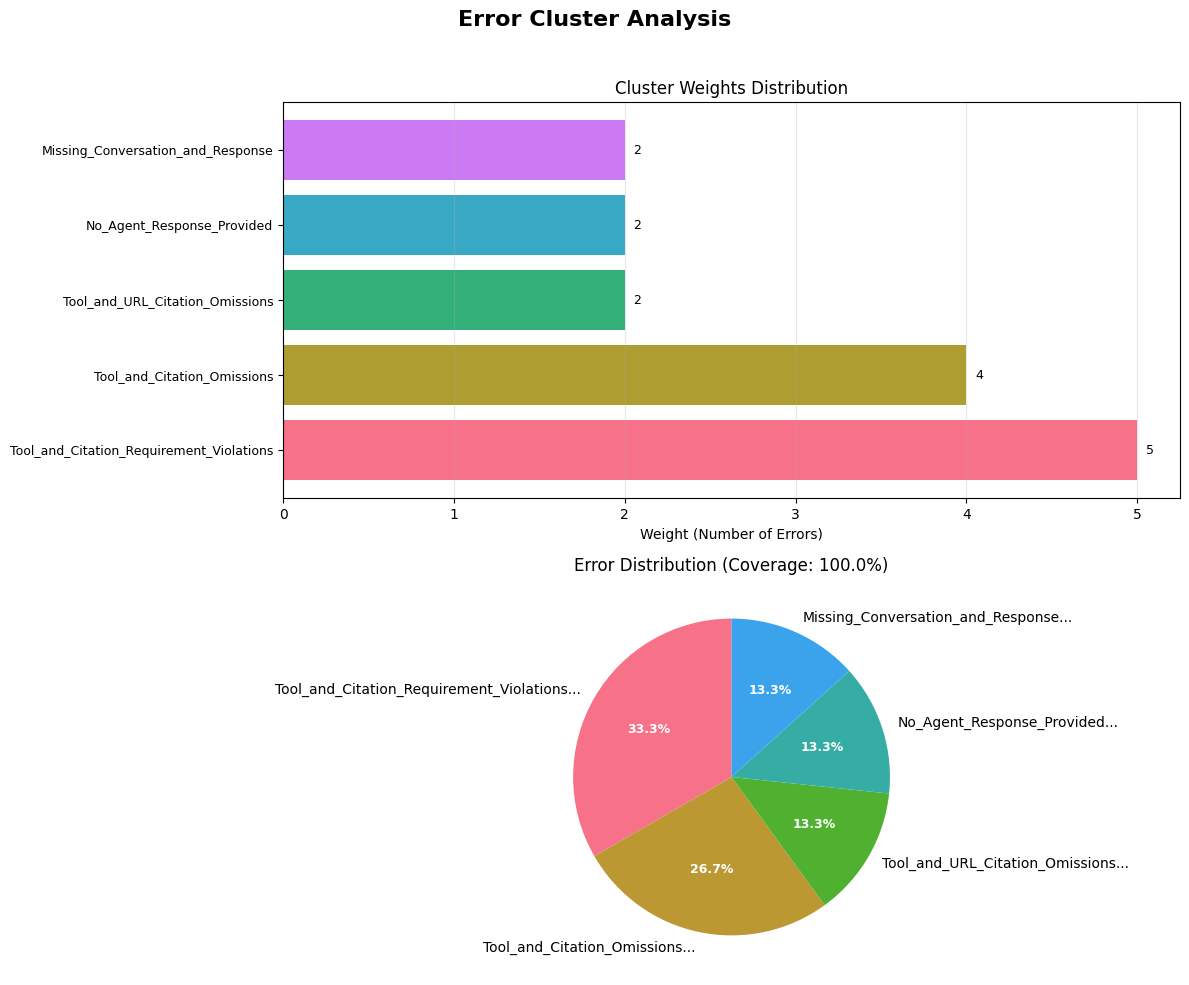

In [21]:
# Visualize the error clusters
critic_agent.visualize_errors(
    error_analysis_report=report
)


In [24]:
# drill down into a specific error cluster
critic_agent.interactive_error_analysis(
    error_analysis_report=report,
    original_evaluations=results,
)

using model gpt-4.1
🎯 Interactive Error Analysis Dashboard
💡 Instructions:
   • Click on pie chart slices to explore clusters
   • Click on bar chart bars to see individual samples
   • Use back buttons to navigate between levels



In [25]:
from error_analyzer import ErrorAnalyzer
analyzer = ErrorAnalyzer()
report = analyzer.generate_enhanced_report(
    evaluations = results,
    fails_only = True,
    num_clusters = 5
)
report


using model gpt-4.1
Step 1: Filtering imperfect evaluations...
Step 2: Extracting error patterns...
Step 3: Generating short error tags...
Step 4: Clustering error tags...
Step 5: Generating LLM analysis...


{'summary': {'total_evaluations': 31,
  'imperfect_evaluations': 13,
  'total_issues': 15,
  'filter_mode': 'fails_only',
  'unique_error_types': 13,
  'total_reasons_analyzed': 15},
 'patterns': {'evaluation_types': defaultdict(int,
              {'TaskAdherence': 13, 'IntentResolution': 2}),
  'score_distribution': defaultdict(<function error_analyzer.ErrorAnalyzer.extract_error_patterns.<locals>.<lambda>()>,
              {'TaskAdherence': defaultdict(int, {2.0: 11, 1.0: 2}),
               'IntentResolution': defaultdict(int, {1.0: 2})}),
  'reasons': defaultdict(list,
              {'TaskAdherence': ['The assistant provided accurate pricing, a free trial link, a logical explanation, and a follow-up question. However, it failed to use the required bing_custom_search tool and did not include citations in the specified format, violating mandatory system rules.',
                'The assistant provided accurate pricing, a free trial link, a follow-up question, and a concise, friendly 

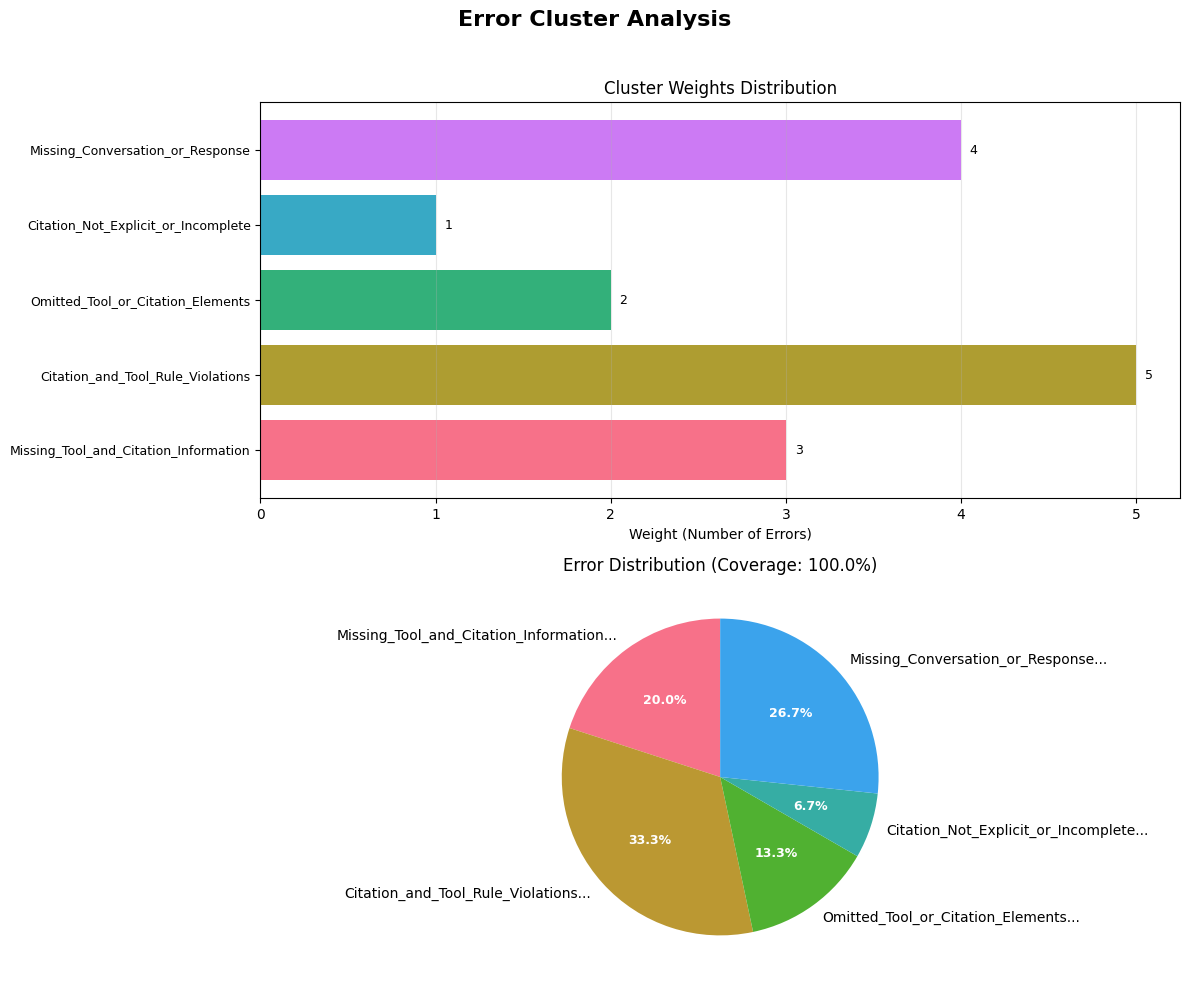

In [30]:
analyzer.visualize_cluster_results(
    cluster_results = report["error_clusters"]
)

In [31]:
analyzer.create_interactive_drill_down(report, original_evaluations=results)

🎯 Interactive Error Analysis Dashboard
💡 Instructions:
   • Click on pie chart slices to explore clusters
   • Click on bar chart bars to see individual samples
   • Use back buttons to navigate between levels

